Num GPUs Available:  1
Loading data...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(



Training the Neural Network...
Epoch 1/300
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - domain_accuracy: 0.1834 - domain_loss: 1.9262 - fault_accuracy: 0.3140 - fault_loss: 1.3633 - loss: 2.7116
Epoch 1: val_fault_accuracy improved from None to 0.23961, saving model to Best_Robust_Model.keras

Epoch 1: finished saving model to Best_Robust_Model.keras
186/186 ━━━━━━━━━━━━━━━━━━━━ 65s 204ms/step - domain_accuracy: 0.2312 - domain_loss: 1.8008 - fault_accuracy: 0.3287 - fault_loss: 1.3279 - loss: 2.5906 - val_domain_accuracy: 0.6247 - val_domain_loss: 1.0670 - val_fault_accuracy: 0.2396 - val_fault_loss: 1.4263 - val_loss: 2.1750
Epoch 2/300
185/186 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - domain_accuracy: 0.2308 - domain_loss: 1.6711 - fault_accuracy: 0.3734 - fault_loss: 1.2629 - loss: 2.4327
Epoch 2: val_fault_accuracy improved from 0.23961 to 0.36192, saving model to Best_Robust_Model.keras

Epoch 2: finished saving model to Best_Robust_Model.keras
186/186 ━━━━━━━━━━━━━━━━━━━━ 18s 94ms/st

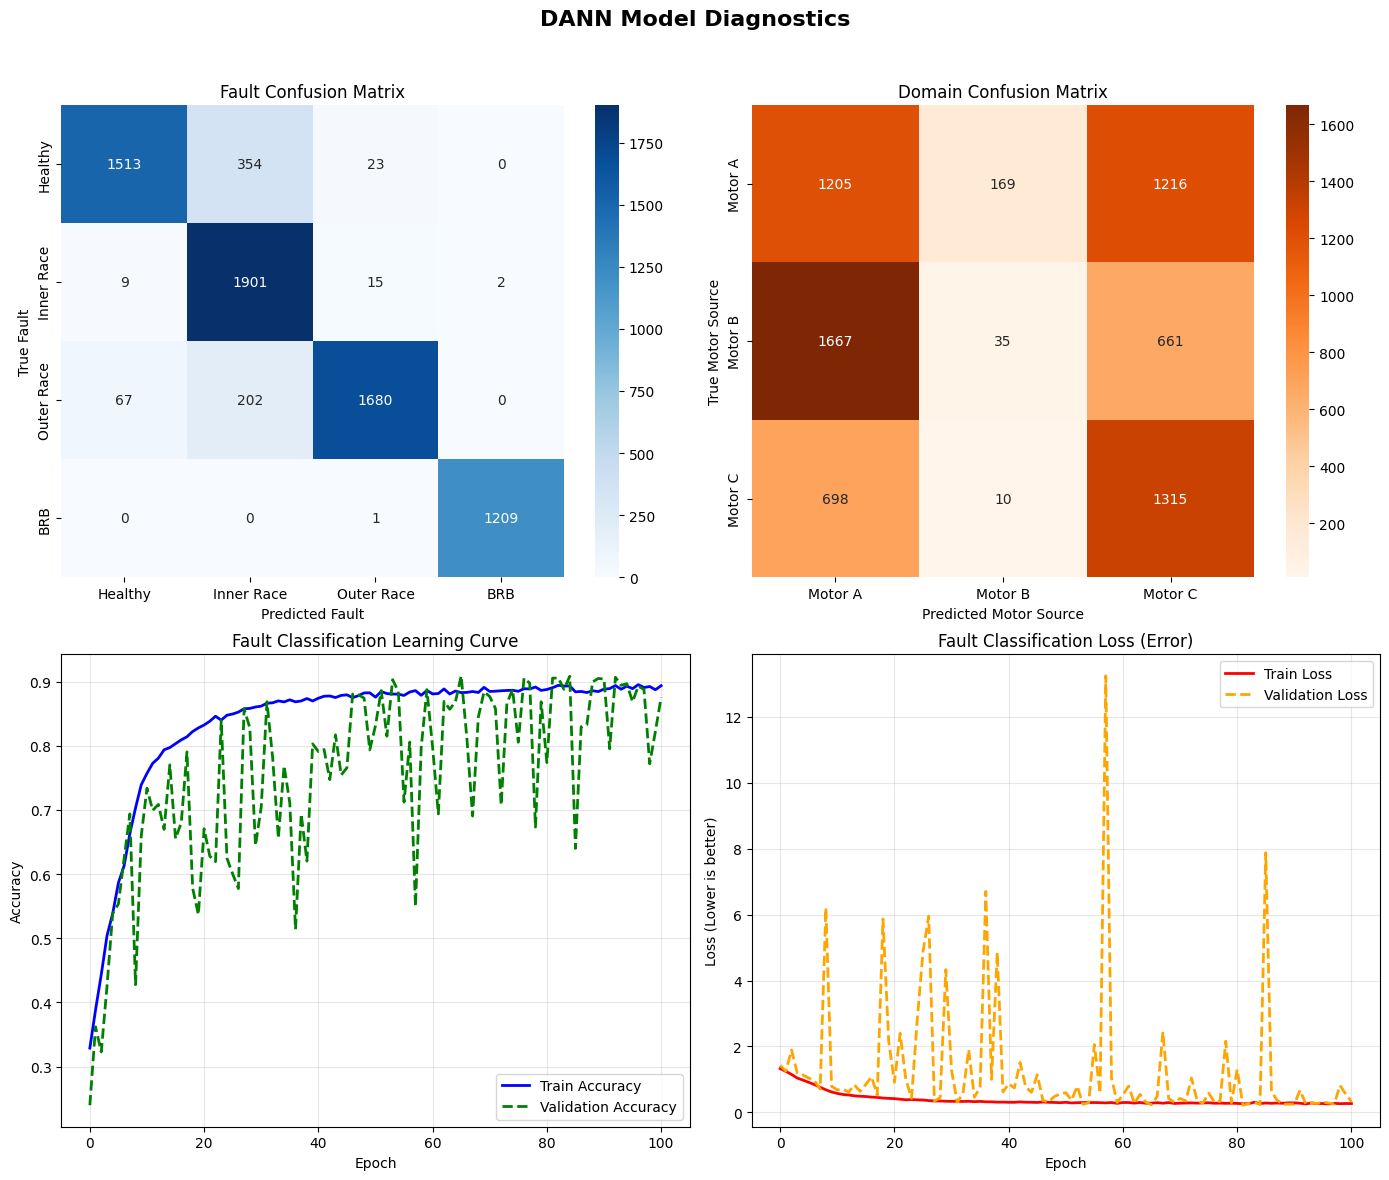

In [ ]:
import numpy as np
import tensorflow as tf
import os
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 0. REPRODUCIBILITY & SETUP
# ==========================================
# Setting random seeds ensures that every time you run this script, 
# the weights initialize the same way and the train/test split is identical. 
# This is crucial for scientifically comparing different model tweaks.
tf.keras.utils.set_random_seed(42)
np.random.seed(42)
random.seed(42)

# Check if TensorFlow recognizes the GPU to speed up training
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# ==========================================
# 1. LOAD AND PREPARE DATA
# ==========================================
print("Loading data...")
# Loading pre-processed .npy arrays is vastly faster than parsing raw CSVs.
# X = Frequency spectrum tensors, y_f = Health state, y_d = Motor ID
X_A, y_f_A, y_d_A = np.load("MotorA_X.npy"), np.load("MotorA_y_fault.npy"), np.load("MotorA_y_domain.npy")
X_B, y_f_B, y_d_B = np.load("MotorB_X.npy"), np.load("MotorB_y_fault.npy"), np.load("MotorB_y_domain.npy")
X_C, y_f_C, y_d_C = np.load("MotorC_X.npy"), np.load("MotorC_y_fault.npy"), np.load("MotorC_y_domain.npy")

# Stack all three distinct motors into one massive, universal dataset
X = np.concatenate([X_A, X_B, X_C])
y_f = np.concatenate([y_f_A, y_f_B, y_f_C])
y_d = np.concatenate([y_d_A, y_d_B, y_d_C])

# Reserve a pristine 20% of the data for the final, unseen test evaluation.
# random_state=42 guarantees we carve out the exact same 20% every time.
X_train, X_test, yf_train, yf_test, yd_train, yd_test = train_test_split(
    X, y_f, y_d, test_size=0.2, random_state=42
)

# ==========================================
# CUSTOM GRADIENT REVERSAL LAYER (GRL)
# ==========================================
# The GRL is the mathematical engine of the Domain-Adversarial Neural Network.
@tf.custom_gradient
def grad_reverse(x, alpha=1.0):
    # Backward Pass: Multiply the gradient by a negative scalar (-alpha).
    # This "punishes" the feature extractor if the domain classifier guesses correctly,
    # forcing the network to unlearn motor-specific noise.
    def custom_grad(dy):
        return -alpha * dy, None
    # Forward Pass: Act as an identity function (do nothing, just pass data through).
    return tf.identity(x), custom_grad

class GradientReversal(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(GradientReversal, self).__init__(**kwargs)
        # Alpha dictates how aggressively the network fights domain memorization.
        self.alpha = tf.Variable(0.0, trainable=False, dtype=tf.float32, name='alpha')

    def call(self, x):
        return grad_reverse(x, self.alpha)

# Slowly ramps up the adversarial penalty (alpha) as training progresses.
# Early epochs focus on learning basic fault shapes (alpha is near 0).
# Later epochs aggressively strip away motor-specific domain traits (alpha approaches 1.5).
class AlphaUpdateCallback(tf.keras.callbacks.Callback):
    def __init__(self, max_epochs):
        self.max_epochs = max_epochs
    def on_epoch_begin(self, epoch, logs=None):
        p = epoch / self.max_epochs
        new_alpha = (2.5 / (1.0 + np.exp(-8.0 * p)) - 1.0) * 1.5
        for layer in self.model.layers:
            if isinstance(layer, GradientReversal):
                tf.keras.backend.set_value(layer.alpha, new_alpha)

# ==========================================
# 2. DEFINE THE DANN ARCHITECTURE
# ==========================================
def build_dann(input_shape=(1000, 3)):
    inputs = tf.keras.Input(shape=input_shape)
    
    # Introduce tiny artificial perturbations to make the model robust against sensor noise
    x = tf.keras.layers.GaussianNoise(0.015)(inputs)

    # --- FEATURE EXTRACTOR (Shared across both outputs) ---
    # Block 1: Large kernel (11) captures broad, fundamental frequency shapes
    x = tf.keras.layers.Conv1D(64, 11, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x) # Stabilizes training mathematically
    x = tf.keras.layers.LeakyReLU(alpha=0.1)(x) # Prevents "dead neurons" by allowing negative leaks
    x = tf.keras.layers.Conv1D(64, 11, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)      # Compresses data dimension to highlight key peaks
    x = tf.keras.layers.Dropout(0.1)(x)         # Randomly turns off 10% of neurons to prevent overfitting

    # Block 2: Decreasing kernel size (7) to capture tighter harmonic details
    x = tf.keras.layers.Conv1D(128, 7, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)
    x = tf.keras.layers.Conv1D(128, 7, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.Dropout(0.1)(x)

    # Block 3: Kernel size (5)
    x = tf.keras.layers.Conv1D(256, 5, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)
    x = tf.keras.layers.Conv1D(256, 5, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.Dropout(0.1)(x)

    # Block 4: Smallest kernel (3) for ultra fine-grained high-frequency noise/fault mapping
    x = tf.keras.layers.Conv1D(512, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x) # Flattens the final 1D map into a 1D vector

    # Bottleneck Layer: Forces the network to compress everything it learned into 256 core features
    x = tf.keras.layers.Dense(256)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)
    features = tf.keras.layers.Dropout(0.2)(x)

    # --- OUTPUT BRANCH 1: THE FAULT PREDICTOR ---
    # Attempts to accurately classify the physical motor fault (Target: High Accuracy)
    f_dense = tf.keras.layers.Dense(64)(features)
    f_act = tf.keras.layers.LeakyReLU(alpha=0.1)(f_dense)
    f_drop = tf.keras.layers.Dropout(0.1)(f_act)
    # Softmax output squashes raw numbers into percentages summing to 1.0 (e.g., 90% BRB, 10% Healthy)
    fault_out = tf.keras.layers.Dense(4, activation='softmax', name='fault')(f_drop)

    # --- OUTPUT BRANCH 2: THE DOMAIN PREDICTOR (ADVERSARIAL) ---
    # Attempts to guess which motor (A, B, or C) the data came from. 
    # Because it is connected via the GRL, it forces the Feature Extractor to become blind to the motor.
    grl_layer = GradientReversal(name='grl')(features)
    d_dense1 = tf.keras.layers.Dense(128)(grl_layer)
    d_norm1 = tf.keras.layers.BatchNormalization()(d_dense1)
    d_act1 = tf.keras.layers.LeakyReLU(alpha=0.1)(d_norm1)
    d_drop1 = tf.keras.layers.Dropout(0.3)(d_act1)
    d_dense2 = tf.keras.layers.Dense(64)(d_drop1)
    d_norm2 = tf.keras.layers.BatchNormalization()(d_dense2)
    d_act2 = tf.keras.layers.LeakyReLU(alpha=0.1)(d_norm2)
    d_drop2 = tf.keras.layers.Dropout(0.2)(d_act2)
    domain_out = tf.keras.layers.Dense(3, activation='softmax', name='domain')(d_drop2)

    # Combine into a dual-output architecture
    model = tf.keras.models.Model(inputs=inputs, outputs=[fault_out, domain_out])
    return model

model = build_dann()

# ==========================================
# 3. COMPILATION & TRAINING
# ==========================================
# AdamW limits exploding weights during complex adversarial backpropagation
safe_optimizer = tf.keras.optimizers.AdamW(learning_rate=0.0003, weight_decay=0.004, clipnorm=1.0)

# Compile with two losses. We weight the fault prediction slightly higher (1.0) 
# than the domain prediction (0.7) to prioritize saving the motor over purely tricking the network.
model.compile(optimizer=safe_optimizer,
              loss={'fault': 'sparse_categorical_crossentropy', 'domain': 'sparse_categorical_crossentropy'},
              loss_weights={'fault': 1.0, 'domain': 0.7},
              metrics={'fault': 'accuracy', 'domain': 'accuracy'})

# Callbacks to manage the training loop safely
# ModelCheckpoint: Automatically saves the `.keras` file at the exact peak of validation accuracy
checkpoint = tf.keras.callbacks.ModelCheckpoint("Best_Robust_Model.keras", monitor='val_fault_accuracy', save_best_only=True, mode='max', verbose=1)
# EarlyStopping: Halts training if the model stagnates for 35 epochs, preventing overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_fault_accuracy', patience=35, mode='max', restore_best_weights=True, verbose=1)

print("\nTraining the Neural Network...")
history = model.fit(X_train, {'fault': yf_train, 'domain': yd_train}, validation_split=0.15, epochs=300, batch_size=128,
                    callbacks=[early_stopping, checkpoint, AlphaUpdateCallback(max_epochs=300)])


# ==========================================
# 4. FINAL ACCURACY SCORING
# ==========================================
print("\n=======================================")
print("         FINAL MODEL SCORES            ")
print("=======================================")

# FIX: Find the exact epoch where the Validation Accuracy was at its absolute best
best_epoch_index = np.argmax(history.history['val_fault_accuracy'])

# Extract the Training and Validation scores from THAT specific best epoch
best_train_acc = history.history['fault_accuracy'][best_epoch_index]
best_val_acc = history.history['val_fault_accuracy'][best_epoch_index]

print(f"1. Training Accuracy:   {best_train_acc * 100:.2f}% (How well it memorized the training data)")
print(f"2. Validation Accuracy: {best_val_acc * 100:.2f}% (How well it performs on the validation splits)")

# Predict on the completely unseen Test Set
predictions = model.predict(X_test)
fault_preds = np.argmax(predictions[0], axis=1) # The fault branch predictions
domain_preds = np.argmax(predictions[1], axis=1) # The domain branch predictions

test_fault_acc = accuracy_score(yf_test, fault_preds)
test_domain_acc = accuracy_score(yd_test, domain_preds)

print(f"3. TEST SET ACCURACY:   {test_fault_acc * 100:.2f}% (The Ultimate Unseen Test)")
print("---------------------------------------")
# Important: Because there are 3 motors, random guessing is 33.3%. 
# If test_domain_acc drops to ~33%, it proves the adversarial layer worked perfectly!
print(f"Domain Trick Accuracy:  {test_domain_acc * 100:.2f}% (Goal is closer to 33%!)")
print("=======================================\n")

# Save the absolute final architecture to your hard drive
model.save("Generalized_Motor_DANN.keras")
print("Model successfully saved to disk!")

# ==========================================
# 5. VISUALIZATIONS (DIAGNOSTICS)
# ==========================================
fault_labels = ['Healthy', 'Inner Race', 'Outer Race', 'BRB']
domain_labels = ['Motor A', 'Motor B', 'Motor C']

# Setup a 2x2 grid for diagnostic charts
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("DANN Model Diagnostics", fontsize=16, fontweight='bold')

# --- Chart 1: Fault Confusion Matrix ---
# Shows exactly which physical faults the AI confused with one another
cm_fault = confusion_matrix(yf_test, fault_preds)
sns.heatmap(cm_fault, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=fault_labels, yticklabels=fault_labels)
axes[0, 0].set_title('Fault Confusion Matrix')
axes[0, 0].set_ylabel('True Fault')
axes[0, 0].set_xlabel('Predicted Fault')

# --- Chart 2: Domain Confusion Matrix ---
# Shows how thoroughly the model was tricked regarding the source motor
cm_domain = confusion_matrix(yd_test, domain_preds)
sns.heatmap(cm_domain, annot=True, fmt='d', cmap='Oranges', ax=axes[0, 1],
            xticklabels=domain_labels, yticklabels=domain_labels)
axes[0, 1].set_title('Domain Confusion Matrix')
axes[0, 1].set_ylabel('True Motor Source')
axes[0, 1].set_xlabel('Predicted Motor Source')

# --- Chart 3: Fault Learning Curve (Accuracy) ---
# Visualizes how fast the model learned to detect faults over time
axes[1, 0].plot(history.history['fault_accuracy'], label='Train Accuracy', color='blue', linewidth=2)
axes[1, 0].plot(history.history['val_fault_accuracy'], label='Validation Accuracy', color='green', linestyle='--', linewidth=2)
axes[1, 0].set_title('Fault Classification Learning Curve')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# --- Chart 4: Fault Learning Curve (Loss) ---
# Visualizes the reduction of mathematical error during gradient descent
axes[1, 1].plot(history.history['fault_loss'], label='Train Loss', color='red', linewidth=2)
axes[1, 1].plot(history.history['val_fault_loss'], label='Validation Loss', color='orange', linestyle='--', linewidth=2)
axes[1, 1].set_title('Fault Classification Loss (Error)')
axes[1, 1].set_ylabel('Loss (Lower is better)')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()